In [1]:
!pip -q install tensorflow scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 806.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 55.4 MB/s eta 0:00:00


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TensorFlow version: 2.21.0
GPU available: []


**Hyperparameters**

In [3]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

VOCAB_SIZE = 20000
MAX_LEN = 250
EMBED_DIM = 128
LSTM_UNITS = 128
BATCH_SIZE = 32
EPOCHS = 5
VAL_SIZE = 5000

**Load dataset**

In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

print("Train:", len(x_train))
print("Test :", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: 25000
Test : 25000


**Padding**

In [5]:
x_train = keras.preprocessing.sequence.pad_sequences(
    x_train, maxlen=MAX_LEN, padding="post", truncating="post"
)

x_test = keras.preprocessing.sequence.pad_sequences(
    x_test, maxlen=MAX_LEN, padding="post", truncating="post"
)

print(x_train.shape, x_test.shape)

(25000, 250) (25000, 250)


**Validation split**

In [6]:
x_val = x_train[:VAL_SIZE]
y_val = y_train[:VAL_SIZE]

x_train_partial = x_train[VAL_SIZE:]
y_train_partial = y_train[VAL_SIZE:]

**Build BiLSTM model**

In [7]:
bilstm_model = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    layers.SpatialDropout1D(0.2),
    layers.Bidirectional(
        layers.LSTM(LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2)
    ),
    layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [8]:
bilstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Train model**

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )
]

start_time = time.time()

history = bilstm_model.fit(
    x_train_partial,
    y_train_partial,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 295s 468ms/step - accuracy: 0.7071 - loss: 0.5692 - val_accuracy: 0.7364 - val_loss: 0.5480
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 280s 449ms/step - accuracy: 0.8280 - loss: 0.4018 - val_accuracy: 0.7910 - val_loss: 0.4535
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 279s 447ms/step - accuracy: 0.8837 - loss: 0.3036 - val_accuracy: 0.8456 - val_loss: 0.3778
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 279s 447ms/step - accuracy: 0.8938 - loss: 0.2810 - val_accuracy: 0.8320 - val_loss: 0.4298
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 279s 447ms/step - accuracy: 0.9125 - loss: 0.2432 - val_accuracy: 0.8236 - val_loss: 0.4534
Training time: 1413.53 seconds


**Evaluate**

In [10]:
test_loss, test_acc = bilstm_model.evaluate(
    x_test,
    y_test,
    batch_size=BATCH_SIZE,
    verbose=0
)

print("Test Loss    :", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))

Test Loss    : 0.4218
Test Accuracy: 0.8266


**Metrics**

In [11]:
y_pred_prob = bilstm_model.predict(x_test, batch_size=BATCH_SIZE, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(test_acc, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 0.8266
Precision: 0.833
Recall   : 0.8169
F1-score : 0.8249


**Confusion matrix**

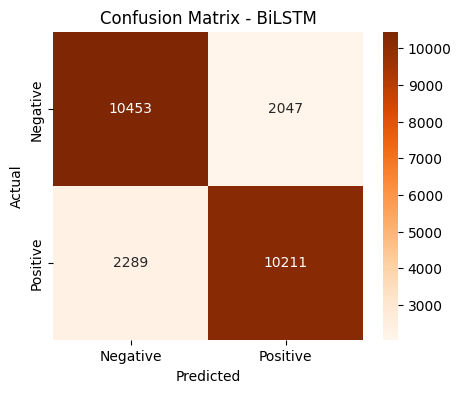

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title("Confusion Matrix - BiLSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Learning curve**

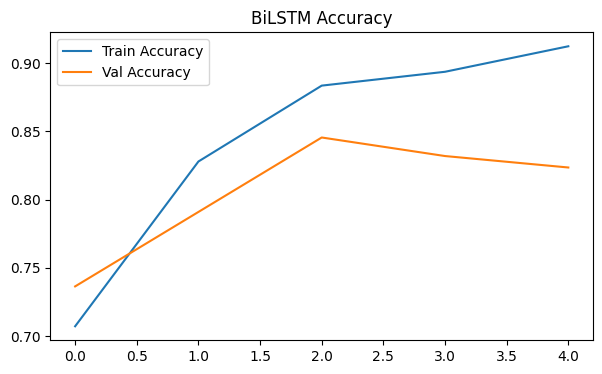

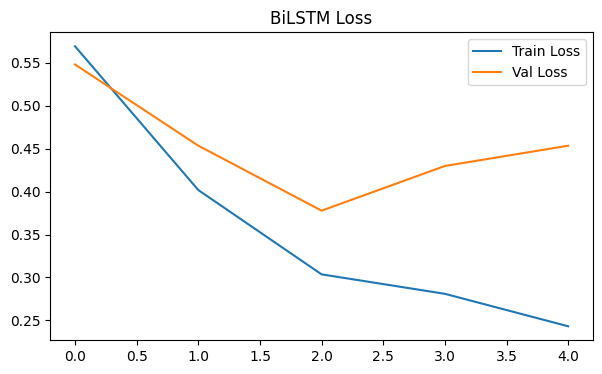

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("BiLSTM Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("BiLSTM Loss")
plt.legend()
plt.show()

**Error analysis**

In [14]:
errors = np.where(y_pred != y_test)[0]

print("Total errors:", len(errors))
print("Sample errors:", errors[:3])

Total errors: 4336
Sample errors: [3 5 6]


In [15]:
for idx in errors[:3]:
    print("True:", y_test[idx], "| Pred:", y_pred[idx])
    print(decode_review(x_test[idx][:150]))
    print("="*80)

True: 0 | Pred: 1


NameError: name 'decode_review' is not defined